In [8]:
import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 256

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([64, 1024])


seed :  898
torch.Size([512, 33])
[[ 1.4104325   7.0510883   6.2251196   4.3825665   3.1667218   6.9532723
   3.3287625  -1.032506   -3.3656807  -6.8151054   4.1683474   0.46010995
  -0.8143431   4.440421   -0.25414604 -2.0945787  -3.0038147  -2.2891674
   1.834253    5.7548776   8.040648    2.42313    -2.1829147  -0.90414834
   2.7109003  -3.4603043   1.028914   -1.3218606   3.596497   -4.145717
   5.0000014  -5.8937025  -1.7916181  -1.0236378   5.5571127  -5.1780186
  -1.7474122  -0.9897457   0.5731418   0.9031982  -0.5839644   0.24535382
  -0.44924185 -2.2855604  -2.9668288  -4.3421326  -2.4922428   1.1139563
   3.8472295   4.379979    0.98399466  1.2251865  -1.2792704   1.1360867
  -2.8422503  -1.2821432   0.70936245  4.8885603  -8.783546   -3.444439
   4.866457   -1.3415759   3.586854    6.893822  ]]


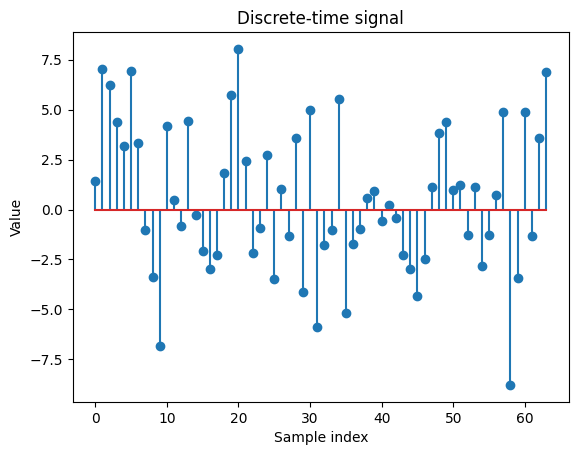

(512, 33)


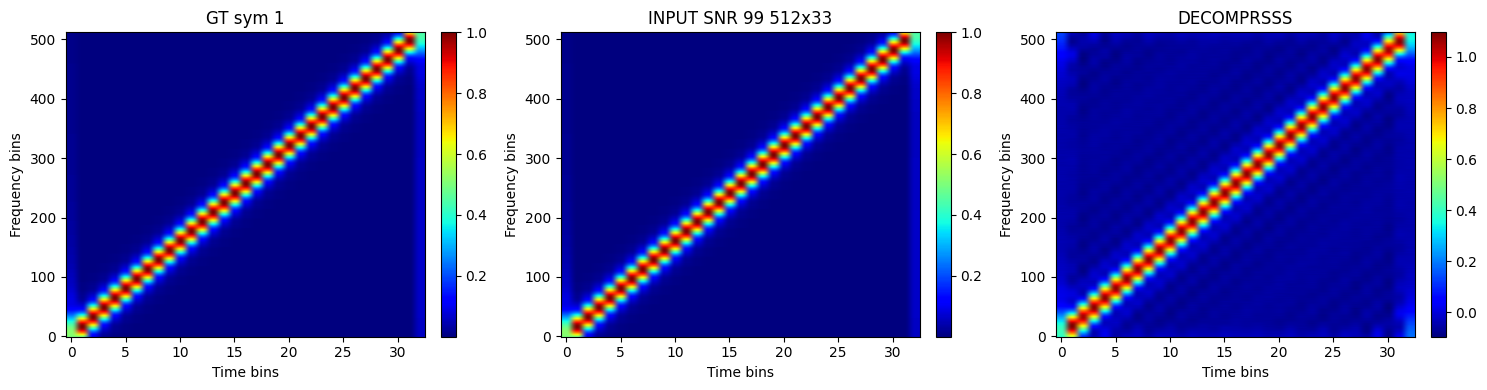

RMSE :  0.06589491199521506
RMPE :  0.004342139426857137
RMSE - to signal max ratio = 6.010 %
RMSE - to signal mean ratio = 53.803 %
Error Vector Magnitude = 0.303 => 30.265 %
RMSE :  0.06589491199521506
RMPE :  0.004342139426857137
RMSE - to signal max ratio = 6.010 %
RMSE - to signal mean ratio = 53.803 %
Error Vector Magnitude = 0.303 => 30.265 %


np.float64(0.06589491199521506)

In [ ]:
symbol1 = 1
# EXAMPLE OF COMPRESS and DECOMPRESS
random_ = np.random.randint(1, 999)  # integer from 1 to 10 (inclusive)
print("seed : ",random_)
seed = random_
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = 10
x = lora_init.awgn_iq_with_seed(x1,snr,None)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam.compress(flat)
print(out1)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()

out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([64, 1024])
torch.Size([512, 33])


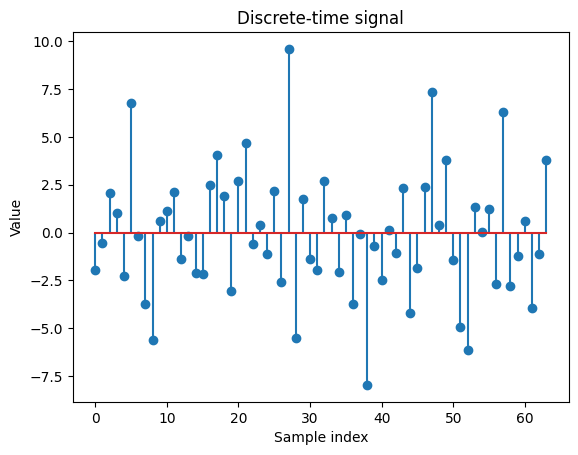

(512, 33)


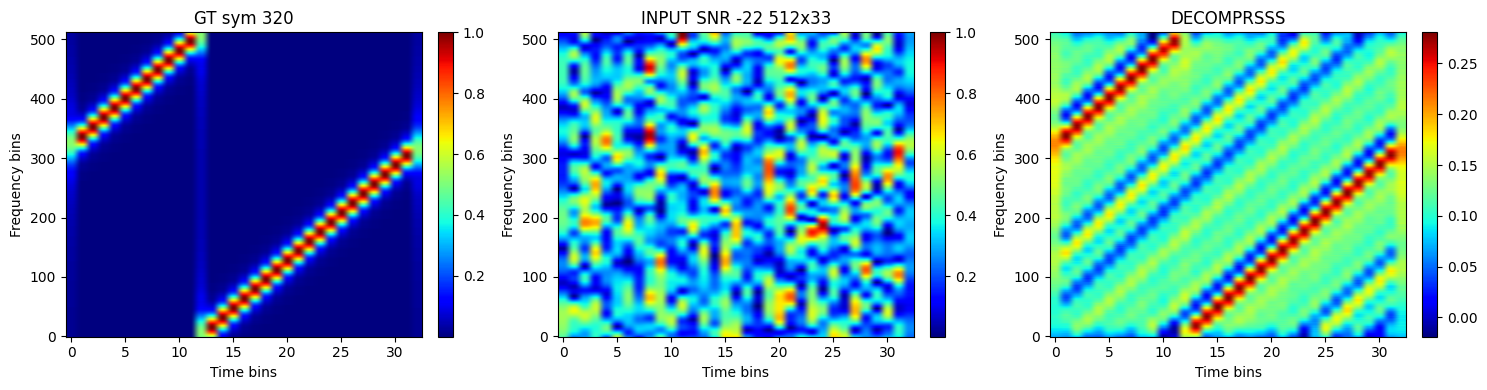

RMSE :  0.27216274072741714
RMPE :  0.07407255744025927
RMSE - to signal max ratio = 96.978 %
RMSE - to signal mean ratio = 231.168 %
Error Vector Magnitude = 0.729 => 72.905 %
RMSE :  0.18225275788828174
RMPE :  0.03321606775788464
RMSE - to signal max ratio = 64.941 %
RMSE - to signal mean ratio = 154.801 %
Error Vector Magnitude = 0.837 => 83.691 %


np.float64(0.18225275788828174)

In [11]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 64

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam2 = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam2.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


symbol1 = 320
# EXAMPLE OF COMPRESS and DECOMPRESS
seed = seed
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = -22
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam2.compress(flat)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()
out2 = multi_bam2.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
# -------------------------------
# PARAMETERS
# -------------------------------
sf = sf
bw = bw
fs = fs
input_row = input_row
input_col = input_col

snr = 0
seed = 591

plt.ion()  # interactive mode ON
fig, ax = plt.subplots(figsize=(10, 4))

# -------------------------------
# LOOP OVER SYMBOLS
# -------------------------------
active = False
if active:
        
    for symbol in range(0, 512):
        clear_output(wait=True)
        # 1. Generate clean symbol
        x1 = lora_init.gen_symbol_fs(symbol, sf=sf, bw=bw, Fs=fs)

        # 2. Add noise (fixed seed for reproducibility)
        # x = lora_init.awgn_iq_with_seed(x1, snr, seed)

        # 3. Spectrogram
        input_spec = create_spectrogram_from_torch(
            x1, sf, bw, fs,
            input_row, input_col,
            0, 0, 1, None
        )

        # 4. Flatten before compress
        flat = input_spec.flatten().reshape(1, -1)

        # 5. Compress
        out = multi_bam.compress(flat)
        a = out.squeeze()

        # -------------------------------
        # PLOTTING (movie style)
        # -------------------------------
        plt.figure(figsize=(10,4))
        plt.bar(np.arange(len(a)), a)
        plt.ylim(-15, 15)
        plt.yticks(np.arange(-15, 15, 1)) 
        plt.title(f"Compressed Representation | Symbol = {symbol}")
        plt.xlabel("Latent Dimension")
        plt.ylabel("Value")
        plt.show()

    plt.ioff()  # interactive mode OFF


KeyboardInterrupt: 